# Lab 6 — SMS Spam Classification with a Bidirectional LSTM
**Teaching focus:** leakage-safe text preprocessing, token sequences, embeddings, class imbalance, appropriate metrics, and probability thresholds.

The notebook expects `spam.csv` in the same folder. All preprocessing used at inference time is included inside the Keras model.

## Imports and reproducibility

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Load and clean the SMS data

In [2]:
DATA_PATH = Path("spam.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Place spam.csv in the same folder as this notebook.")

raw = pd.read_csv(DATA_PATH, encoding="latin-1")
df = raw.loc[:, ["v1", "v2"]].rename(columns={"v1": "label", "v2": "message"})
df = df.dropna().drop_duplicates().reset_index(drop=True)

print(df.head())
print(df["label"].value_counts())
print("Rows after cleaning:", len(df))

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
label
ham     4516
spam     653
Name: count, dtype: int64
Rows after cleaning: 5169


## Encode labels and create stratified splits

In [3]:
labels = df["label"].map({"ham": 0, "spam": 1}).astype("int32").to_numpy()
messages = df["message"].astype(str).to_numpy()

from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(
    messages,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels,
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

print("Train/validation/test:", len(x_train), len(x_val), len(x_test))

Train/validation/test: 3618 775 776


## Create and adapt the text vectorizer

In [4]:
MAX_TOKENS = 5000
SEQUENCE_LENGTH = 80

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    standardize="lower_and_strip_punctuation",
)
vectorizer.adapt(x_train)

vocabulary = vectorizer.get_vocabulary()
print("Vocabulary size:", len(vocabulary))
print("Example token IDs:", vectorizer(x_train[:1]).numpy()[0, :15])

Vocabulary size: 5000
Example token IDs: [157 750  51 454  67   4 125   0   0   0   0   0   0   0   0]


> **Leakage checkpoint:** Explain why `adapt(x_train)` is correct but `adapt(messages)` is not.

## Build the end-to-end model

In [5]:
model = keras.Sequential([
    layers.Input(shape=(), dtype=tf.string, name="sms_text"),
    vectorizer,
    layers.Embedding(
        input_dim=len(vocabulary),
        output_dim=64,
        mask_zero=True,
        name="embedding",
    ),
    layers.Bidirectional(layers.LSTM(32), name="bidirectional_lstm"),
    layers.Dropout(0.30, name="dropout"),
    layers.Dense(1, activation="sigmoid", name="spam_probability"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ text_vectorization                   │ (None, 80)                  │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 80, 64)              │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_lstm (Bidirectional)   │ (None, 64)                  │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spam_probability (Dense)             │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 344,897 (1.32 MB)

 Trainable params: 344,897 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

## Compile and train

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    )
]

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/10
57/57 - 8s - 136ms/step - accuracy: 0.8698 - loss: 0.4265 - precision: 0.3793 - recall: 0.0481 - val_accuracy: 0.9200 - val_loss: 0.1952 - val_precision: 0.9737 - val_recall: 0.3776
Epoch 2/10
57/57 - 2s - 43ms/step - accuracy: 0.9740 - loss: 0.1037 - precision: 0.9666 - recall: 0.8228 - val_accuracy: 0.9742 - val_loss: 0.0819 - val_precision: 0.9239 - val_recall: 0.8673
Epoch 3/10
57/57 - 2s - 42ms/step - accuracy: 0.9928 - loss: 0.0364 - precision: 0.9865 - recall: 0.9562 - val_accuracy: 0.9768 - val_loss: 0.0719 - val_precision: 0.9545 - val_recall: 0.8571
Epoch 4/10
57/57 - 3s - 47ms/step - accuracy: 0.9970 - loss: 0.0183 - precision: 0.9956 - recall: 0.9803 - val_accuracy: 0.9794 - val_loss: 0.0707 - val_precision: 0.9457 - val_recall: 0.8878
Epoch 5/10
57/57 - 3s - 50ms/step - accuracy: 0.9989 - loss: 0.0092 - precision: 1.0000 - recall: 0.9912 - val_accuracy: 0.9781 - val_loss: 0.0766 - val_precision: 0.9263 - val_recall: 0.8980
Epoch 6/10
57/57 - 2s - 43ms/step - acc

## Plot validation behaviour

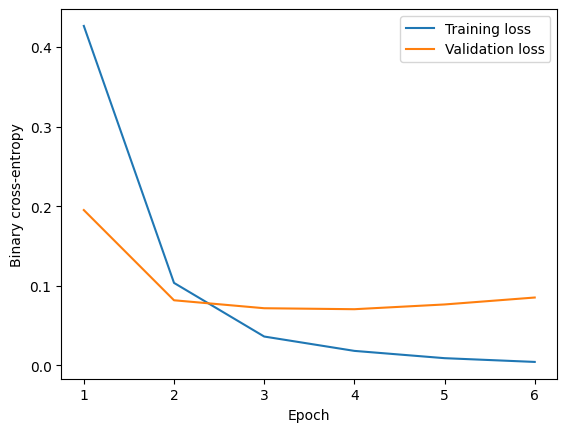

In [7]:
epochs_run = range(1, len(history.history["loss"]) + 1)
plt.plot(epochs_run, history.history["loss"], label="Training loss")
plt.plot(epochs_run, history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.legend()
plt.show()

## Final evaluation and confusion matrix

{'accuracy': 0.9858, 'loss': 0.0568, 'precision': 0.9677, 'recall': 0.9184}
              precision    recall  f1-score   support

         ham      0.988     0.996     0.992       678
        spam      0.968     0.918     0.942        98

    accuracy                          0.986       776
   macro avg      0.978     0.957     0.967       776
weighted avg      0.986     0.986     0.986       776



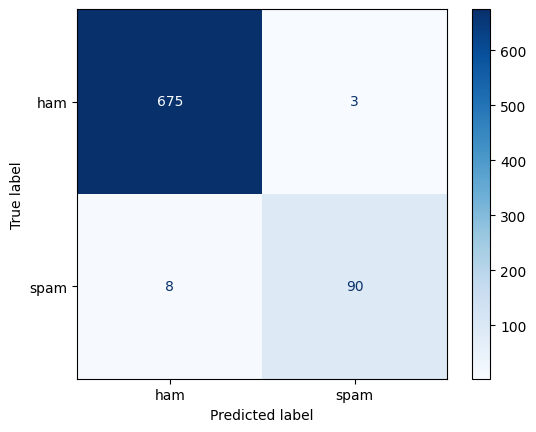

In [8]:
test_metrics = model.evaluate(x_test, y_test, return_dict=True, verbose=0)
print({name: round(value, 4) for name, value in test_metrics.items()})

test_probabilities = model.predict(x_test, verbose=0).reshape(-1)
test_predictions = (test_probabilities >= 0.50).astype("int32")

from sklearn.metrics import ConfusionMatrixDisplay, classification_report
print(classification_report(y_test, test_predictions, target_names=["ham", "spam"], digits=3))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["ham", "spam"],
    cmap="Blues",
)
plt.show()

> **Decision checkpoint:** If missing spam is more costly than flagging ham, should the threshold move above or below 0.50?

## Predict new messages safely

In [9]:
def classify_messages(messages_to_classify, threshold=0.50):
    message_tensor = tf.constant(messages_to_classify, dtype=tf.string)
    spam_probabilities = model.predict(message_tensor, verbose=0).reshape(-1)
    predicted_names = np.where(spam_probabilities >= threshold, "spam", "ham")
    return pd.DataFrame({
        "message": list(messages_to_classify),
        "spam_probability": spam_probabilities,
        "prediction": predicted_names,
    })

examples = [
    "Ok lar... Joking wif u oni...",
    "URGENT! You have won a free prize. Call now!",
]

classify_messages(examples)

,message,spam_probability,prediction
0,Ok lar... Joking wif u oni...,0.000242,ham
1,URGENT! You have won a free prize. Call now!,0.991507,spam


## Extension tasks
1. Compare `LSTM(32)`, `GRU(32)`, and `SimpleRNN(32)` using the same split.
2. Try thresholds 0.30, 0.50, and 0.70. Record spam precision and recall.
3. Remove `Bidirectional` and explain when future context would be unavailable in a real deployment.
4. Inspect five false positives and five false negatives. Propose one data-centric improvement.